<a href="https://colab.research.google.com/github/Ariqueeezz/Enterprise-Brand-Sentiment-and-Campaign-Analytics-Pipeline/blob/epic%2FEBSCAP-9/EBSCAP_1_EBSCAP_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **EBSCAP-3: Download dan standardisasi dataset skala besar**

In [6]:
import os

base = "/content"
raw_dir = f"{base}/raw"
processed_dir = f"{base}/processed"
torch_dir = f"{base}/torch_ready"

for d in [raw_dir, processed_dir, torch_dir]:
    os.makedirs(d, exist_ok=True)

In [8]:
import requests
from tqdm import tqdm

url = "https://mcauleylab.ucsd.edu/public_datasets/data/amazon_2023/raw/review_categories/All_Beauty.jsonl.gz"
dest = f"{raw_dir}/All_Beauty.jsonl.gz"

response = requests.get(url, stream=True)
response.raise_for_status()
total_size = int(response.headers.get('content-length', 0))

with open(dest, 'wb') as f, tqdm(desc="All_Beauty.jsonl.gz", total=total_size,
                                   unit='iB', unit_scale=True, unit_divisor=1024) as bar:
    for chunk in response.iter_content(chunk_size=8192):
        size = f.write(chunk)
        bar.update(size)

print(f"Ukuran: {os.path.getsize(dest) / (1024**2):.2f} MB")

All_Beauty.jsonl.gz: 100%|██████████| 90.1M/90.1M [00:04<00:00, 19.6MiB/s]

Ukuran: 90.07 MB


# **EBSCAP-4: Setup local/cloud PySpark session dan sinkronisasi skema**

In [9]:
from pyspark.sql import SparkSession
from pyspark.sql.types import (
    StructType, StructField, StringType, DoubleType,
    BooleanType, LongType, ArrayType
)

spark = (
    SparkSession.builder
    .appName("BrandSentimentPipeline")
    .config("spark.driver.memory", "6g")
    .config("spark.sql.shuffle.partitions", "8")
    .getOrCreate()
)

review_schema = StructType([
    StructField("rating", DoubleType(), True),
    StructField("title", StringType(), True),
    StructField("text", StringType(), True),
    StructField("images", ArrayType(StringType()), True),
    StructField("asin", StringType(), True),
    StructField("parent_asin", StringType(), True),
    StructField("user_id", StringType(), True),
    StructField("timestamp", LongType(), True),
    StructField("verified_purchase", BooleanType(), True),
    StructField("helpful_vote", LongType(), True),
])

df = spark.read.schema(review_schema).json(f"{raw_dir}/All_Beauty.jsonl.gz")
df.printSchema()
print(f"Total rows: {df.count():,}")

df.cache()

root
 |-- rating: double (nullable = true)
 |-- title: string (nullable = true)
 |-- text: string (nullable = true)
 |-- images: array (nullable = true)
 |    |-- element: string (containsNull = true)
 |-- asin: string (nullable = true)
 |-- parent_asin: string (nullable = true)
 |-- user_id: string (nullable = true)
 |-- timestamp: long (nullable = true)
 |-- verified_purchase: boolean (nullable = true)
 |-- helpful_vote: long (nullable = true)

Total rows: 701,528


DataFrame[rating: double, title: string, text: string, images: array<string>, asin: string, parent_asin: string, user_id: string, timestamp: bigint, verified_purchase: boolean, helpful_vote: bigint]

In [10]:
df.show(5, truncate=50)

+------+-----------------------------------------+--------------------------------------------------+------+----------+-----------+----------------------------+-------------+-----------------+------------+
|rating|                                    title|                                              text|images|      asin|parent_asin|                     user_id|    timestamp|verified_purchase|helpful_vote|
+------+-----------------------------------------+--------------------------------------------------+------+----------+-----------+----------------------------+-------------+-----------------+------------+
|   5.0|Such a lovely scent but not overpowering.|This spray is really nice. It smells really goo...|    []|B00YQ6X8EO| B00YQ6X8EO|AGKHLEW2SOWHNMFQIJGBECAF7INQ|1588687728923|             true|           0|
|   4.0|   Works great but smells a little weird.|This product does what I need it to do, I just ...|    []|B081TJ8YS3| B081TJ8YS3|AGKHLEW2SOWHNMFQIJGBECAF7INQ|1588615855070|  

In [11]:
print(f"Total rows: {df.count():,}")
print(f"Total columns: {len(df.columns)}")

Total rows: 701,528
Total columns: 10


# **EBSCAP-5: Lakukan Exploratory Data Analysis (EDA) terdistribusi menggunakan Spark SQL**

## Distribusi Rating per-Review

In [20]:
df.createOrReplaceTempView("reviews")
rating_dist = spark.sql("""
    SELECT
        rating,
        COUNT(*) AS jumlah_review,
        ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (), 2) AS persentase
    FROM reviews
    GROUP BY rating
    ORDER BY rating
""")
rating_dist.show()

+------+-------------+----------+
|rating|jumlah_review|persentase|
+------+-------------+----------+
|   1.0|       102080|     14.55|
|   2.0|        43034|      6.13|
|   3.0|        56307|      8.03|
|   4.0|        79381|     11.32|
|   5.0|       420726|     59.97|
+------+-------------+----------+



## Mendeteksi Missing Values

In [21]:
from pyspark.sql.functions import col, sum as spark_sum, when

null_counts = df.select([
    spark_sum(when(col(c).isNull(), 1).otherwise(0)).alias(c)
    for c in df.columns
])
null_counts.show(truncate=False)

+------+-----+----+------+----+-----------+-------+---------+-----------------+------------+
|rating|title|text|images|asin|parent_asin|user_id|timestamp|verified_purchase|helpful_vote|
+------+-----+----+------+----+-----------+-------+---------+-----------------+------------+
|0     |0    |0   |0     |0   |0          |0      |0        |0                |0           |
+------+-----+----+------+----+-----------+-------+---------+-----------------+------------+



## Ringkasan data 'text' atau ulasan pengguna keseluruhan review

In [22]:
from pyspark.sql.functions import length, split, size

df_with_wordcount = df.withColumn(
    "word_count", size(split(col("text"), " "))
)
df_with_wordcount.createOrReplaceTempView("reviews_wc")

word_stats = spark.sql("""
    SELECT
        MIN(word_count) AS min_kata,
        MAX(word_count) AS max_kata,
        ROUND(AVG(word_count), 1) AS rata_rata_kata,
        PERCENTILE_APPROX(word_count, 0.5) AS median_kata
    FROM reviews_wc
""")
word_stats.show()

+--------+--------+--------------+-----------+
|min_kata|max_kata|rata_rata_kata|median_kata|
+--------+--------+--------------+-----------+
|       1|    2624|          33.2|         20|
+--------+--------+--------------+-----------+



In [23]:
word_by_rating = spark.sql("""
    SELECT
        rating,
        ROUND(AVG(word_count), 1) AS rata_rata_kata,
        COUNT(*) AS jumlah_review
    FROM reviews_wc
    GROUP BY rating
    ORDER BY rating
""")
word_by_rating.show()

+------+--------------+-------------+
|rating|rata_rata_kata|jumlah_review|
+------+--------------+-------------+
|   1.0|          30.6|       102080|
|   2.0|          37.2|        43034|
|   3.0|          39.4|        56307|
|   4.0|          43.0|        79381|
|   5.0|          30.6|       420726|
+------+--------------+-------------+



## Distribusi pengguna yang ter-verifikasi membeli produk yang di review

In [24]:
spark.sql("""
    SELECT verified_purchase, COUNT(*) AS jumlah
    FROM reviews
    GROUP BY verified_purchase
""").show()

+-----------------+------+
|verified_purchase|jumlah|
+-----------------+------+
|             true|634969|
|            false| 66559|
+-----------------+------+



## Visualisasi distribusi rating

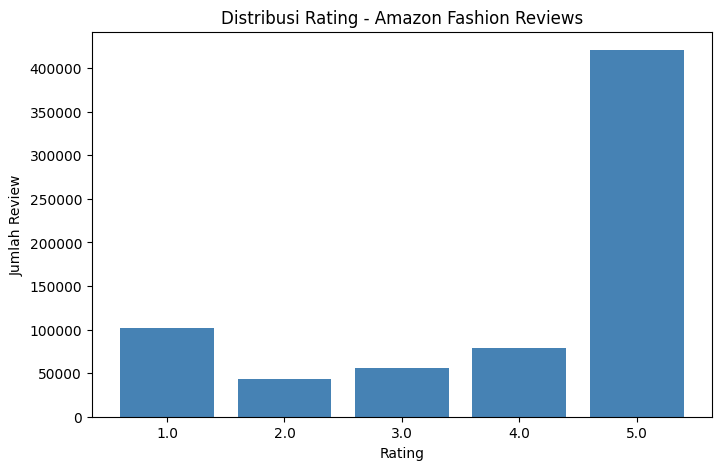

In [25]:
import matplotlib.pyplot as plt

rating_pd = rating_dist.toPandas()

plt.figure(figsize=(8, 5))
plt.bar(rating_pd["rating"].astype(str), rating_pd["jumlah_review"], color="steelblue")
plt.xlabel("Rating")
plt.ylabel("Jumlah Review")
plt.title("Distribusi Rating - Amazon Fashion Reviews")
plt.show()

# **EBSCAP-7: Implementasi regex cleaner terdistribusi via PySpark UDF**

In [13]:
!pip install emoji -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 15.5 MB/s eta 0:00:00


In [15]:
from pyspark.sql.functions import col, regexp_replace, trim, lower, length
import emoji
from pyspark.sql.functions import udf
from pyspark.sql.types import StringType

df_clean = df.withColumn("text_clean", regexp_replace(col("text"), r"<[^>]+>", " "))
df_clean = df_clean.withColumn("text_clean", regexp_replace(col("text_clean"), r"http\S+|www\.\S+", " "))
df_clean = df_clean.withColumn("text_clean", regexp_replace(col("text_clean"), r"[^a-zA-Z0-9\s.,!?']", " "))
df_clean = df_clean.withColumn("text_clean", trim(regexp_replace(col("text_clean"), r"\s+", " ")))

def remove_emoji(text):
    return emoji.replace_emoji(text, replace=' ') if text else text

remove_emoji_udf = udf(remove_emoji, StringType())
df_clean = df_clean.withColumn("text_clean", remove_emoji_udf(col("text_clean")))
df_clean = df_clean.withColumn("text_clean", lower(col("text_clean")))
df_clean = df_clean.filter(length(trim(col("text_clean"))) > 0)

df_clean.cache()
df_clean.select("text", "text_clean").show(5, truncate=80)

+--------------------------------------------------------------------------------+--------------------------------------------------------------------------------+
|                                                                            text|                                                                      text_clean|
+--------------------------------------------------------------------------------+--------------------------------------------------------------------------------+
|This spray is really nice. It smells really good, goes on really fine, and do...|this spray is really nice. it smells really good, goes on really fine, and do...|
|This product does what I need it to do, I just wish it was odorless or had a ...|this product does what i need it to do, i just wish it was odorless or had a ...|
|                                                       Smells good, feels great!|                                                       smells good, feels great!|
|               

In [16]:
df_clean.write.mode("overwrite").parquet(f"{processed_dir}/reviews_clean.parquet")

In [17]:
df_clean = df_clean.withColumn("text_clean", lower(col("text_clean")))

# Filter baris yang jadi kosong/terlalu pendek setelah cleaning (data quality)
from pyspark.sql.functions import length

df_clean = df_clean.filter(length(trim(col("text_clean"))) > 0)

In [18]:
df_clean.select("text", "text_clean").show(5, truncate=80)

# Bandingkan jumlah baris sebelum & sesudah filter kosong
print(f"Baris sebelum cleaning: {df.count():,}")
print(f"Baris sesudah cleaning: {df_clean.count():,}")

+--------------------------------------------------------------------------------+--------------------------------------------------------------------------------+
|                                                                            text|                                                                      text_clean|
+--------------------------------------------------------------------------------+--------------------------------------------------------------------------------+
|This spray is really nice. It smells really good, goes on really fine, and do...|this spray is really nice. it smells really good, goes on really fine, and do...|
|This product does what I need it to do, I just wish it was odorless or had a ...|this product does what i need it to do, i just wish it was odorless or had a ...|
|                                                       Smells good, feels great!|                                                       smells good, feels great!|
|               

In [19]:
df_clean.cache()
df_clean.count()    # trigger cache

699910

# **EBSCAP-8: Bangun pipeline tokenisasi dan text vectorization (Word2Vec) menggunakan PySpark ML**

In [26]:
from pyspark.ml.feature import Tokenizer, StopWordsRemover, HashingTF, IDF, Word2Vec

# Tokenisasi
tokenizer = Tokenizer(inputCol="text_clean", outputCol="tokens_raw")
df_tokens = tokenizer.transform(df_clean)

# Stopwords (exclude kata negasi — penting utk sentimen)
default_stopwords = StopWordsRemover.loadDefaultStopWords("english")
negation_words = {"not", "no", "nor", "never", "none", "neither",
                   "don't", "doesn't", "didn't", "won't", "wouldn't",
                   "can't", "cannot", "isn't", "aren't", "wasn't", "weren't"}
custom_stopwords = [w for w in default_stopwords if w not in negation_words]

remover = StopWordsRemover(inputCol="tokens_raw", outputCol="tokens_clean", stopWords=custom_stopwords)
df_tokens = remover.transform(df_tokens)

# TF-IDF
hashing_tf = HashingTF(inputCol="tokens_clean", outputCol="raw_features", numFeatures=20000)
df_tf = hashing_tf.transform(df_tokens)
idf = IDF(inputCol="raw_features", outputCol="tfidf_features")
idf_model = idf.fit(df_tf)
df_tfidf = idf.fit(df_tf).transform(df_tf)

# Word2Vec
word2vec = Word2Vec(vectorSize=100, minCount=5, inputCol="tokens_clean", outputCol="w2v_features")
word2vec_model = word2vec.fit(df_tokens)
df_w2v = word2vec_model.transform(df_tokens)

word2vec_model.findSynonyms("gentle", 5).show()

+---------+------------------+
|     word|        similarity|
+---------+------------------+
|  gentle,| 0.766068696975708|
|  gentle.|0.6956191658973694|
|   gental|0.6135683655738831|
| delicate|0.6076240539550781|
|sensitive|0.5999680757522583|
+---------+------------------+



# **EBSCAP-11: Konversi output PySpark DataFrame ke format Tensor**

In [27]:
import numpy as np
import pickle
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from pyspark.sql.functions import when

# Label sentimen
df_labeled = df_w2v.withColumn(
    "sentiment_label",
    when(col("rating") <= 2, 0).when(col("rating") == 3, 1).otherwise(2)
)
df_labeled.groupBy("sentiment_label").count().show()

# Vocabulary & embedding matrix dari Word2Vec
vocab_pd = word2vec_model.getVectors().toPandas()

PAD_TOKEN, UNK_TOKEN = "<PAD>", "<UNK>"
word_list = [PAD_TOKEN, UNK_TOKEN] + vocab_pd["word"].tolist()
word2idx = {word: idx for idx, word in enumerate(word_list)}

embedding_dim = len(vocab_pd["vector"].iloc[0])
embedding_matrix = np.zeros((len(word_list), embedding_dim), dtype=np.float32)
embedding_matrix[1] = np.random.normal(scale=0.1, size=embedding_dim)
for i, row in vocab_pd.iterrows():
    embedding_matrix[word2idx[row["word"]]] = np.array(row["vector"])

# Collect ke Pandas (hindari UDF — lesson learned dari error sebelumnya)
df_model_input = df_labeled.select("tokens_clean", "sentiment_label").toPandas()

MAX_LEN = 100  # sesuaikan dgn median_kata dari Task 1.3
PAD_IDX, UNK_IDX = word2idx[PAD_TOKEN], word2idx[UNK_TOKEN]

def tokens_to_indices_local(tokens):
    indices = [word2idx.get(t, UNK_IDX) for t in tokens][:MAX_LEN]
    if len(indices) < MAX_LEN:
        indices += [PAD_IDX] * (MAX_LEN - len(indices))
    return indices

df_model_input["token_indices"] = df_model_input["tokens_clean"].apply(tokens_to_indices_local)

X = np.stack(df_model_input["token_indices"].values)
y = df_model_input["sentiment_label"].values

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

class SentimentDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.long)
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self): return len(self.X)
    def __getitem__(self, idx): return self.X[idx], self.y[idx]

BATCH_SIZE = 64
train_loader = DataLoader(SentimentDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(SentimentDataset(X_val, y_val), batch_size=BATCH_SIZE)
test_loader = DataLoader(SentimentDataset(X_test, y_test), batch_size=BATCH_SIZE)

xb, yb = next(iter(train_loader))
print(f"Batch shape: {xb.shape}, Label shape: {yb.shape}")

# Simpan artifact
np.save(f"{torch_dir}/embedding_matrix.npy", embedding_matrix)
np.save(f"{torch_dir}/X_train.npy", X_train)
np.save(f"{torch_dir}/X_val.npy", X_val)
np.save(f"{torch_dir}/X_test.npy", X_test)
np.save(f"{torch_dir}/y_train.npy", y_train)
np.save(f"{torch_dir}/y_val.npy", y_val)
np.save(f"{torch_dir}/y_test.npy", y_test)
with open(f"{torch_dir}/word2idx.pkl", "wb") as f:
    pickle.dump(word2idx, f)

+---------------+------+
|sentiment_label| count|
+---------------+------+
|              1| 56258|
|              2|498772|
|              0|144880|
+---------------+------+

Batch shape: torch.Size([64, 100]), Label shape: torch.Size([64])
